# Principal Component Analysis (PCA) on Gene Expression Data

This notebook provides a reproducible workflow for performing **Principal Component Analysis (PCA)** on a gene expression matrix. PCA is a dimensionality reduction technique widely used in bioinformatics to:
- Visualize high-dimensional data (thousands of genes) in 2D or 3D space.
- Verify if biological replicates group together (quality control).
- Detect batch effects or outlier samples.
- Identify the main sources of variation in the experiment.

## 1. Imports and Setup

We start by importing the necessary scientific computing and plotting libraries.

In [1]:
import os
import pandas as pd
import numpy as np
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

# Set high-DPI plotting and a clean aesthetic
%matplotlib inline
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 150
plt.rcParams["font.family"] = "sans-serif"

## 2. Load the Expression Matrix

In bioinformatics, the standard format for gene expression data is:
- **Rows**: Genes (features)
- **Columns**: Samples (observations)

However, machine learning packages like `scikit-learn` expect the exact inverse: **samples as rows and features as columns**. 
Therefore, we must **transpose** the matrix after loading it.

In [2]:
# Load matrix
df_raw = pd.read_csv("expression_matrix.csv", index_col=0)

print(f"Raw Expression Matrix shape: {df_raw.shape} (Genes: {df_raw.shape[0]}, Samples: {df_raw.shape[1]})")
df_raw.head()

Raw Expression Matrix shape: (20, 6) (Genes: 20, Samples: 6)


,Ctrl_1,Ctrl_2,Ctrl_3,Trt_1,Trt_2,Trt_3
Gene_ID,,,,,,
GENE_01,5.2,5.3,5.2,10.2,10.3,10.2
GENE_02,6.1,6.1,6.2,11.1,11.2,11.1
GENE_03,4.8,4.7,4.8,9.8,9.7,9.8
GENE_04,7.2,7.3,7.2,12.2,12.3,12.2
GENE_05,5.9,5.9,6.0,10.9,10.9,11.0


### Transposing the Matrix
Let's transpose the matrix so that each row is a sample and each column is a gene.

In [3]:
# Transpose: samples become rows, genes become columns
df_transposed = df_raw.T
print(f"Transposed Matrix shape: {df_transposed.shape} (Samples: {df_transposed.shape[0]}, Genes: {df_transposed.shape[1]})")
df_transposed.head()

Transposed Matrix shape: (6, 20) (Samples: 6, Genes: 20)


Gene_ID,GENE_01,GENE_02,GENE_03,GENE_04,GENE_05,GENE_06,GENE_07,GENE_08,GENE_09,GENE_10,GENE_11,GENE_12,GENE_13,GENE_14,GENE_15,GENE_16,GENE_17,GENE_18,GENE_19,GENE_20
Ctrl_1,5.2,6.1,4.8,7.2,5.9,11.2,10.1,9.8,12.2,10.9,8.0,7.5,9.1,6.4,8.8,5.0,12.0,3.2,9.9,7.1
Ctrl_2,5.3,6.1,4.7,7.3,5.9,11.3,10.1,9.7,12.3,10.9,8.1,7.5,9.0,6.4,8.7,5.1,12.0,3.3,9.8,7.1
Ctrl_3,5.2,6.2,4.8,7.2,6.0,11.2,10.2,9.8,12.2,11.0,8.0,7.6,9.1,6.5,8.8,5.0,12.1,3.2,9.9,7.2
Trt_1,10.2,11.1,9.8,12.2,10.9,6.2,5.1,4.8,7.2,5.9,8.0,7.5,9.1,6.4,8.8,5.0,12.0,3.2,9.9,7.1
Trt_2,10.3,11.2,9.7,12.3,10.9,6.3,5.2,4.7,7.3,5.9,8.1,7.5,9.0,6.4,8.7,5.1,12.0,3.3,9.8,7.1


## 3. Data Preprocessing (Scaling)

PCA is highly sensitive to the variance of the features. If one gene has values ranging from 0 to 1000 and another ranges from 0 to 1, PCA will be dominated by the first gene.

To solve this, we standardize the data using `StandardScaler` (subtracting the mean and dividing by the standard deviation for each gene), so that each gene has:
- **Mean = 0**
- **Variance = 1**

*Note: In some RNA-seq experiments, if the data are already log-transformed or normalized (like TPM/CPM), one might choose to only center the data (mean=0) without scaling the variance, to avoid over-inflating noise from low-abundance transcripts. For this general notebook, we will use standardization as a sensible default.*

In [4]:
# Standardize features
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df_transposed)

# Convert back to DataFrame to preserve labels
df_scaled = pd.DataFrame(scaled_data, index=df_transposed.index, columns=df_transposed.columns)
df_scaled.head()

Gene_ID,GENE_01,GENE_02,GENE_03,GENE_04,GENE_05,GENE_06,GENE_07,GENE_08,GENE_09,GENE_10,GENE_11,GENE_12,GENE_13,GENE_14,GENE_15,GENE_16,GENE_17,GENE_18,GENE_19,GENE_20
Ctrl_1,-1.013153,-1.013153,-0.986491,-1.013153,-1.013153,0.986491,0.986491,1.013153,0.986491,0.986491,-0.707107,-0.707107,0.707107,-0.707107,0.707107,-0.707107,-0.707107,-0.707107,0.707107,-0.707107
Ctrl_2,-0.973160,-1.013153,-1.026484,-0.973160,-1.013153,1.026484,0.986491,0.973160,1.026484,0.986491,1.414214,-0.707107,-1.414214,-0.707107,-1.414214,1.414214,-0.707107,1.414214,-1.414214,-0.707107
Ctrl_3,-1.013153,-0.973160,-0.986491,-1.013153,-0.973160,0.986491,1.026484,1.013153,0.986491,1.026484,-0.707107,1.414214,0.707107,1.414214,0.707107,-0.707107,1.414214,-0.707107,0.707107,1.414214
Trt_1,0.986491,0.986491,1.013153,0.986491,0.986491,-1.013153,-1.013153,-0.986491,-1.013153,-1.013153,-0.707107,-0.707107,0.707107,-0.707107,0.707107,-0.707107,-0.707107,-0.707107,0.707107,-0.707107
Trt_2,1.026484,1.026484,0.973160,1.026484,0.986491,-0.973160,-0.973160,-1.026484,-0.973160,-1.013153,1.414214,-0.707107,-1.414214,-0.707107,-1.414214,1.414214,-0.707107,1.414214,-1.414214,-0.707107


## 4. Run PCA

We fit PCA on our scaled data. Since we have 6 samples, the maximum number of principal components is 6. We will compute all of them to inspect the explained variance.

In [5]:
pca = PCA()
pca_coords = pca.fit_transform(df_scaled)

# Create a DataFrame with the principal component coordinates
pc_cols = [f"PC{i+1}" for i in range(pca_coords.shape[1])]
df_pca = pd.DataFrame(pca_coords, index=df_transposed.index, columns=pc_cols)

# Add group/condition metadata extracted from sample names
# Assumes sample names starting with 'Ctrl' are Controls, and 'Trt' are Treatments
df_pca["Condition"] = ["Control" if name.startswith("Ctrl") else "Treatment" for name in df_pca.index]
df_pca

,PC1,PC2,PC3,PC4,PC5,PC6,Condition
Ctrl_1,-3.161716,-0.649369,-2.140116,0.000004,8.670651e-18,2.606047e-16,Control
Ctrl_2,-3.161716,3.664694,0.757755,-0.028280,-3.916996e-16,2.884369e-18,Control
Ctrl_3,-3.161716,-3.015325,1.382361,0.028276,-3.916996e-16,2.884369e-18,Control
Trt_1,3.161716,-0.649369,-2.140116,0.000004,-5.251564e-16,-8.302242e-17,Treatment
Trt_2,3.161716,3.664739,0.758240,0.028277,-1.247861e-16,1.746980e-16,Treatment
Trt_3,3.161716,-3.015371,1.381877,-0.028281,-1.247861e-16,1.746980e-16,Treatment


## 5. Visualizing Explained Variance (Scree Plot)

A Scree Plot shows how much of the total variance in the dataset is captured by each principal component. This helps us decide how many PCs are necessary to represent the data.

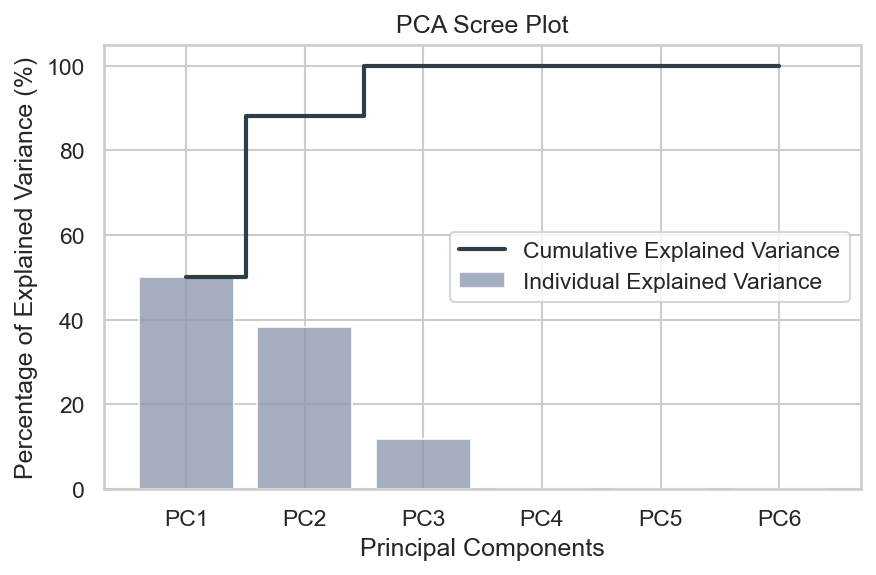

In [6]:
explained_var = pca.explained_variance_ratio_ * 100
cumulative_var = np.cumsum(explained_var)

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(pc_cols, explained_var, color="#8E9AAF", alpha=0.8, label="Individual Explained Variance")
ax.step(pc_cols, cumulative_var, where="mid", color="#2F3E46", linewidth=2, label="Cumulative Explained Variance")

ax.set_ylabel("Percentage of Explained Variance (%)")
ax.set_xlabel("Principal Components")
ax.set_title("PCA Scree Plot")
ax.set_ylim(0, 105)
ax.legend(loc="best")
plt.tight_layout()
plt.show()

## 6. Plotting PCA Components (2D PCA Plot)

We plot PC1 vs PC2 to visualize our samples. We use a curated premium color palette to distinguish the groups cleanly:
- **Control** samples in blue (`#3A86FF`)
- **Treatment** samples in pink (`#FF006E`)

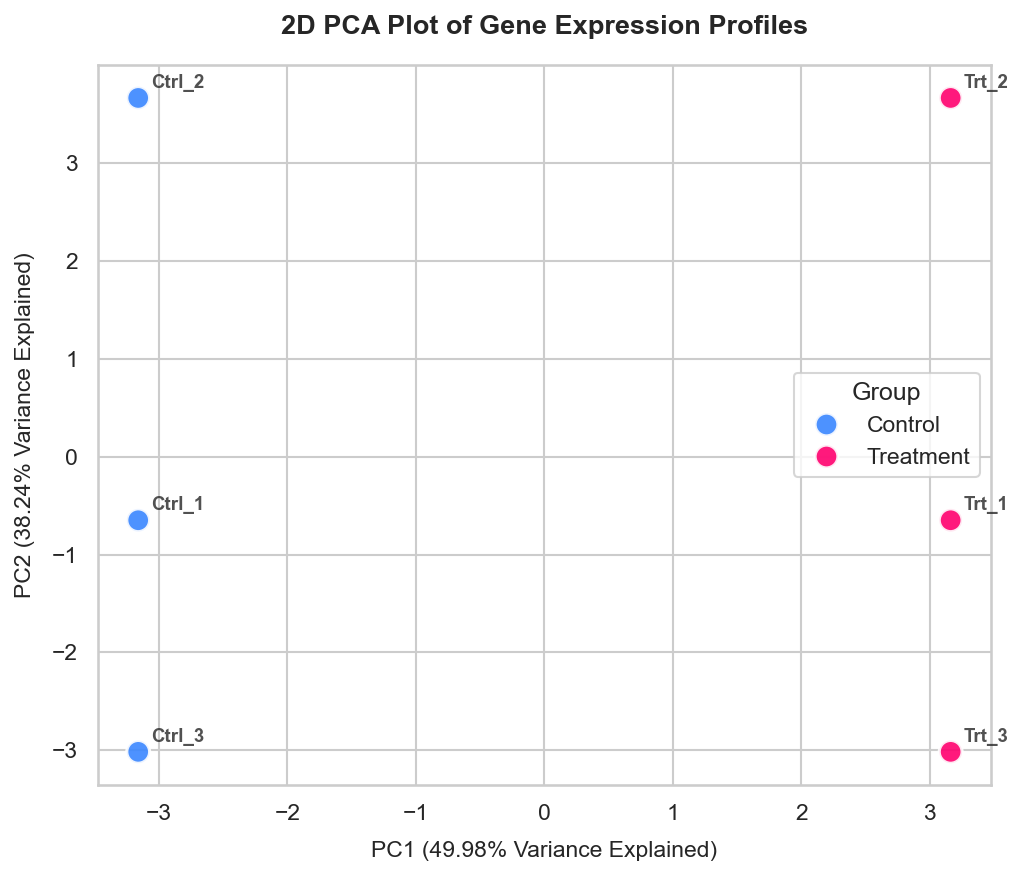

In [7]:
# Extract percentage explained for labels
pc1_var = explained_var[0]
pc2_var = explained_var[1]

colors = {"Control": "#3A86FF", "Treatment": "#FF006E"}

fig, ax = plt.subplots(figsize=(7, 6))

sns.scatterplot(
    data=df_pca,
    x="PC1",
    y="PC2",
    hue="Condition",
    palette=colors,
    s=120,
    edgecolor="w",
    linewidth=1.5,
    alpha=0.9,
    ax=ax
)

# Annotate samples
for sample_name in df_pca.index:
    ax.text(
        df_pca.loc[sample_name, "PC1"] + 0.1,
        df_pca.loc[sample_name, "PC2"] + 0.1,
        sample_name,
        fontsize=9,
        weight="bold",
        alpha=0.8
    )

ax.set_title("2D PCA Plot of Gene Expression Profiles", fontsize=13, weight="bold", pad=15)
ax.set_xlabel(f"PC1 ({pc1_var:.2f}% Variance Explained)", fontsize=11, labelpad=8)
ax.set_ylabel(f"PC2 ({pc2_var:.2f}% Variance Explained)", fontsize=11, labelpad=8)
ax.legend(title="Group", frameon=True)

plt.tight_layout()
plt.show()

## 7. Biological Invariants and Validation Checks

Let's write programmatic assertions to validate that the PCA behavior meets our biological invariants:
1. **Replicate Clustering**: Samples from the same group (Control or Treatment) should group closer to each other on the PC1-PC2 space than to samples from the other group.
2. **Group Separation**: PC1 (which captures the largest variance) should separate Control samples from Treatment samples.

In [8]:
# Biological Invariant 1: PC1 coordinates of Controls and Treatments must not overlap
ctrl_pc1 = df_pca.loc[df_pca["Condition"] == "Control", "PC1"]
trt_pc1 = df_pca.loc[df_pca["Condition"] == "Treatment", "PC1"]

ctrl_max_pc1 = ctrl_pc1.max()
ctrl_min_pc1 = ctrl_pc1.min()
trt_max_pc1 = trt_pc1.max()
trt_min_pc1 = trt_pc1.min()

# Ensure they form separate intervals on PC1
has_separation = (ctrl_max_pc1 < trt_min_pc1) or (trt_max_pc1 < ctrl_min_pc1)
assert has_separation, f"FAILED: Control and Treatment do not separate cleanly on PC1! Control PC1: {ctrl_pc1.values}, Treatment PC1: {trt_pc1.values}"
print("PASSED Biological Invariant 1: Control and Treatment samples separate cleanly on PC1.")

# Biological Invariant 2: Within-group variance should be smaller than between-group variance along PC1
mean_ctrl_pc1 = ctrl_pc1.mean()
mean_trt_pc1 = trt_pc1.mean()
between_group_distance = abs(mean_ctrl_pc1 - mean_trt_pc1)

max_within_group_spread = max(ctrl_max_pc1 - ctrl_min_pc1, trt_max_pc1 - trt_min_pc1)

assert between_group_distance > 2 * max_within_group_spread, "FAILED: Replicates are too scattered relative to the treatment effect!"
print("PASSED Biological Invariant 2: Biological replicates cluster tightly together relative to the condition difference.")

PASSED Biological Invariant 1: Control and Treatment samples separate cleanly on PC1.
PASSED Biological Invariant 2: Biological replicates cluster tightly together relative to the condition difference.
